In [ ]:
import os
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import cv2

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO('yolo11l.pt')

# Train the model
results = model.train(
    data='/kaggle/input/algae-detection/agle-bloom-1/data.yaml',    # Path to your YAML file
    epochs=30,           # Set epochs as required (e.g., 50-100)
    imgsz=640,           # Image size (adjust as needed)
    batch=16,            # Batch size depends on your GPU
    project='runs/train',
    name='exp_yolov11_singleclass',
    # auto_augment="randaugment"
)

# Optional: perform validation
metrics = model.val()
metrics.results_dict

Ultralytics 8.3.174 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/algae-detection/agle-bloom-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=exp_yolov11_singleclass, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspect

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  2    173824  ultralytics.nn.modules.block.C3k2            [128, 256, 2, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  2    691712  ultralytics.nn.modules.block.C3k2            [256, 512, 2, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  2   2234368  ultralytics.nn.modules.block.C3k2            [512, 512, 2, True]           
  7                  -1  1   2360320  ultralytics

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 9.0±3.4 MB/s, size: 69.3 KB)


train: Scanning /kaggle/input/algae-detection/agle-bloom-1/train/labels... 704 images, 0 backgrounds, 0 corrupt: 100%|██████████| 704/704 [00:03<00:00, 191.16it/s]


WARNING ⚠️ train: Cache directory /kaggle/input/algae-detection/agle-bloom-1/train is not writeable, cache not saved.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 15.9±6.3 MB/s, size: 99.5 KB)


...

val: Scanning /kaggle/input/algae-detection/agle-bloom-1/valid/labels... 344 images, 0 backgrounds, 0 corrupt: 100%|██████████| 344/344 [00:00<00:00, 425.83it/s]

WARNING ⚠️ val: Cache directory /kaggle/input/algae-detection/agle-bloom-1/valid is not writeable, cache not saved.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 22/22 [00:12<00:00,  1.78it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        344        474      0.847      0.437      0.489      0.295
Speed: 0.7ms preprocess, 30.9ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/train/exp_yolov11_singleclass2


{'metrics/precision(B)': 0.8467131524868463,
 'metrics/recall(B)': 0.43670886075949367,
 'metrics/mAP50(B)': 0.4892043112525861,
 'metrics/mAP50-95(B)': 0.2954113329234976,
 'fitness': 0.31479063075640645}

In [8]:
metrics = model.val(data='/kaggle/input/algae-detection/agle-bloom-1/data.yaml', batch=16, plots=True) #, imgsz=640)
metrics.results_dict

Ultralytics 8.3.174 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 91.1±47.2 MB/s, size: 108.2 KB)


val: Scanning /kaggle/input/algae-detection/agle-bloom-1/valid/labels... 344 images, 0 backgrounds, 0 corrupt: 100%|██████████| 344/344 [00:00<00:00, 538.37it/s]

WARNING ⚠️ val: Cache directory /kaggle/input/algae-detection/agle-bloom-1/valid is not writeable, cache not saved.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 22/22 [00:12<00:00,  1.76it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        344        474      0.847      0.437      0.489      0.295
Speed: 0.7ms preprocess, 31.7ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/train/exp_yolov11_singleclass3


{'metrics/precision(B)': 0.8467131524868463,
 'metrics/recall(B)': 0.43670886075949367,
 'metrics/mAP50(B)': 0.4892043112525861,
 'metrics/mAP50-95(B)': 0.2954113329234976,
 'fitness': 0.31479063075640645}

In [9]:
model.save('modell.pt') 


WARNING ⚠️ Download failure, retrying 1/3 https://lmcd.org/wp-content/uploads/2021/04/Blue-Green-Cyanobac-20180627_131231-1024x768-1.jpg...


######################################################################## 100.0%


image 1/1 /kaggle/working/Blue-Green-Cyanobac-20180627_131231-1024x768-1.jpg: 480x640 2 Algae Detecteds, 56.5ms
Speed: 2.4ms preprocess, 56.5ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


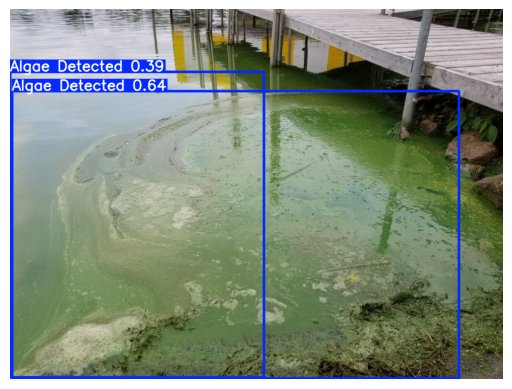

In [ ]:
model1 = YOLO('/kaggle/working/modell.pt')

results = model1('https://lmcd.org/wp-content/uploads/2021/04/Blue-Green-Cyanobac-20180627_131231-1024x768-1.jpg', imgsz=640)

for result in results:
    annotated_bgr = result.plot()
    # Convert to RGB for display with PIL/matplotlib
    annotated_pil = Image.fromarray(annotated_bgr[..., ::-1])
    # Display in Kaggle notebook
    plt.axis('off')
    plt.imshow(annotated_pil)
    plt.show()
    result.save(filename="predicted.jpg")


### Generate annotated image without confidence and optionally without labels/boxes

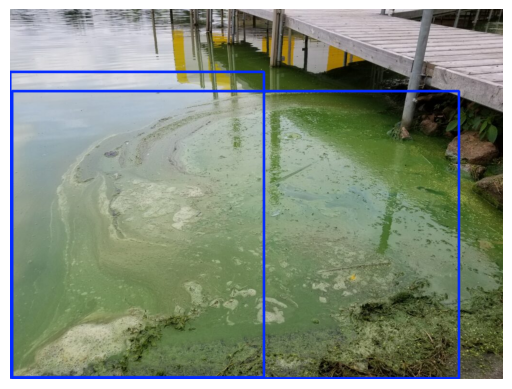

In [ ]:
for result in results:
    img_array = result.plot(conf=False, labels = False)  # Confidence scores are hidden
    img_rgb = Image.fromarray(img_array[..., ::-1])  # Convert BGR to RGB

    plt.axis('off')
    plt.imshow(img_rgb)
    plt.show()

### Annotate objects based on the threshold confidence scores

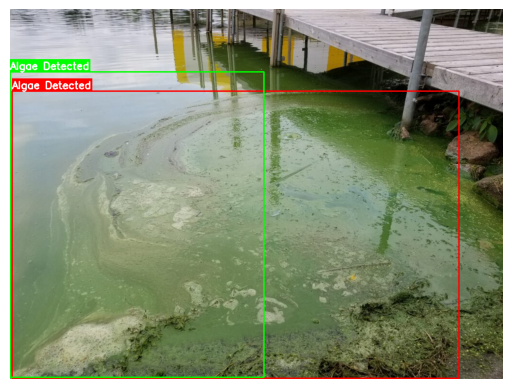

In [ ]:
for i, result in enumerate(results):
    img = result.orig_img.copy()  # Original image as numpy array (BGR)
    for j in range(len(result.boxes)):
        box = result.boxes.xyxy[j].cpu().numpy().astype(int)
        conf = float(result.boxes.conf[j].cpu())
        class_id = int(result.boxes.cls[j].cpu())
        label = result.names[class_id]
        
        # Set box color: red if conf > 0.5 else green
        color = (0, 0, 255) if conf > 0.5 else (0, 255, 0)  # OpenCV uses BGR

        # Draw the bounding box
        cv2.rectangle(img, (box[0], box[1]), (box[2], box[3]), color, 2)
        
        # Draw only the label (not confidence)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        cv2.rectangle(img, (box[0], box[1] - th - 10), (box[0] + tw, box[1]), color, -1)
        cv2.putText(img, label, (box[0], box[1] - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    
    # Convert BGR to RGB for Jupyter display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.axis('off')
    plt.imshow(img_rgb)
    plt.show()
    # Or save: 
    Image.fromarray(img_rgb).save("annotated_image.jpg")


image 1/1 /kaggle/input/test-data/images.jpeg: 448x640 1 Algae Detected, 52.5ms
Speed: 1.7ms preprocess, 52.5ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)


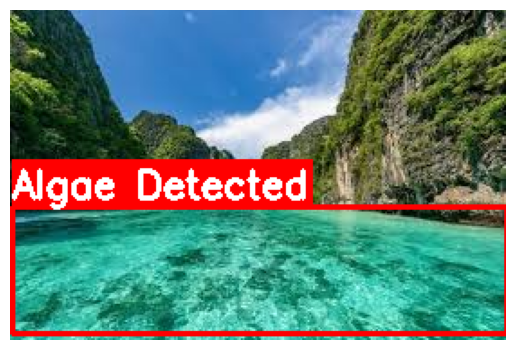

In [ ]:
results = model1('/kaggle/input/test-data/images.jpeg', imgsz=640)

for i, result in enumerate(results):
    img = result.orig_img.copy()  # Original image as numpy array (BGR)
    for j in range(len(result.boxes)):
        box = result.boxes.xyxy[j].cpu().numpy().astype(int)
        conf = float(result.boxes.conf[j].cpu())
        class_id = int(result.boxes.cls[j].cpu())
        label = result.names[class_id]
        
        # Set box color: red if conf > 0.5 else green
        color = (0, 0, 255) if conf > 0.5 else (0, 255, 0)  # OpenCV uses BGR

        # Draw the bounding box
        cv2.rectangle(img, (box[0], box[1]), (box[2], box[3]), color, 2)
        
        # Draw only the label (not confidence)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        cv2.rectangle(img, (box[0], box[1] - th - 10), (box[0] + tw, box[1]), color, -1)
        cv2.putText(img, label, (box[0], box[1] - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    
    # Convert BGR to RGB for Jupyter display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.axis('off')
    plt.imshow(img_rgb)
    plt.show()
    # Or save: 
    Image.fromarray(img_rgb).save("annotated_image.jpg")